# Deep Dive of Exercise Session 0

Below you will find a comprehensive overview of the additional topics and tangential discussions
addressed during Exercise Session 0 that went beyond the scope of the exercise sheet.

In [58]:
%%time
# Magic Commands %lsmagic
# https://ipython.readthedocs.io/en/stable/interactive/magics.html

# % -> line magic
# %% -> cell magic, i.e. %%time

%load_ext autoreload
%autoreload 2

import numpy_test

numpy_test.simple_speed_comparison(10_000_000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python:  1.7074s
NumPy:   0.0301s
Factor: 56.6x faster
CPU times: user 1.67 s, sys: 408 ms, total: 2.08 s
Wall time: 2.08 s


In [59]:
%load_ext autoreload
%autoreload 2

import anaconda_test

anaconda_test.check_python_version()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python Version: 3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
Path: /home/preichel4/anaconda3/envs/python_3_10/bin/python


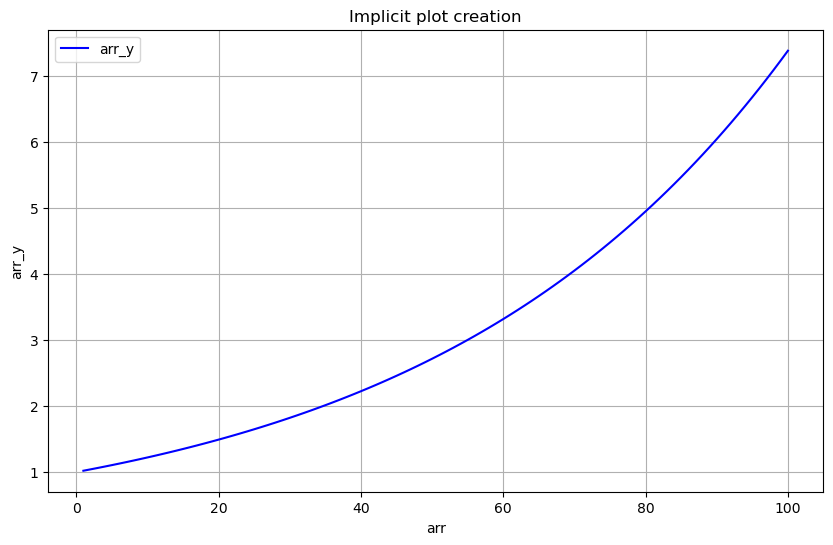

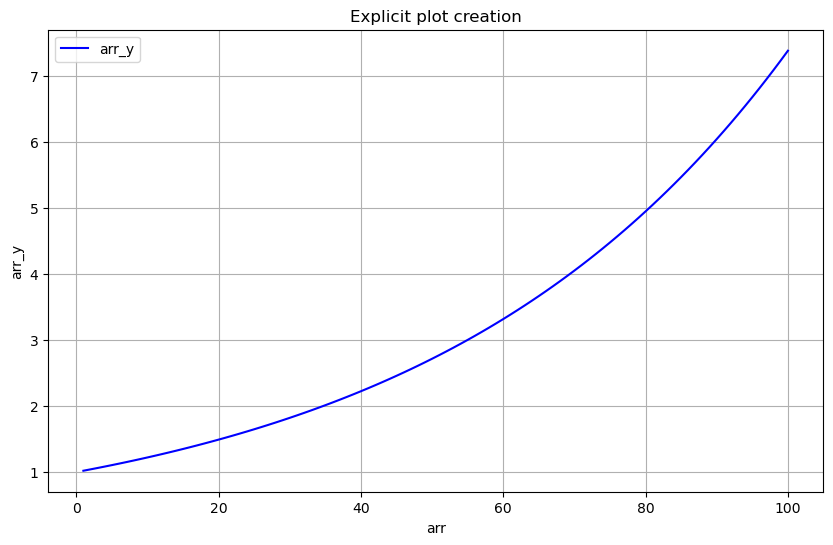

In [60]:
# https://matplotlib.org/stable/users/explain/quick_start.html
import matplotlib.pyplot as plt
import numpy as np

arr = np.arange(1, 101)
arr_y = np.exp(arr / 50)

# implicit way of matplotlib
plt.figure(figsize=(10,6))
plt.plot(arr, arr_y, label='arr_y', color='blue')
plt.xlabel('arr')
plt.ylabel('arr_y')
plt.title('Implicit plot creation')
plt.legend()
plt.grid(True)
plt.show()

# explicit way of matplotlib
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(arr, arr_y, color='blue', label=f'arr_y')
ax.set_xlabel('arr')
ax.set_ylabel('arr_y')
ax.set_title('Explicit plot creation')
ax.legend()
ax.grid(True)
plt.show()

# Be aware of views and shallow copies!

## 1. Reassignment (No Copy)
Reassigning a variable simply points the new variable to the **same object** in memory.
No new object is created. Changes to the object via one variable affect the other. (Labeling)

## 2. Slicing with Mixed Elements (Shallow Copy)

Slicing (`[:]`) creates a new container (`Shallow Copy`).

* Immutable elements (integers, strings): Safe to modify the outer list without affecting the original.
* Mutable elements (nested lists, dicts): The references are copied, not the objects themselves. Modifying a nested mutable object affects both lists.

## 3. Return Statement in Functions

Returning an object from a function does not create a copy. It returns the reference. The caller can mutate the original object.

## 4. Slicing in NumPy (Views vs Copies)
Unlike standard Python lists, NumPy arrays do not create copies when sliced.
They create Views. A view shares the underlying data buffer with the original array. <br>
**Changing the view changes the original!**

In [ ]:
# 1. Reassignment (No Copy)

original = [1, 2, 3]
ref = original  # Reassignment: ref points to the same list object

ref.append(4)

print(original) # Output: [1, 2, 3, 4] -> Original changed!
print(ref)      # Output: [1, 2, 3, 4]

## 2. Slicing with Mixed Elements (Shallow Copy)

# List containing both immutable (int) and mutable (list) elements
original = [10, 'text', [50, 60]]
# Slicing creates a Shallow Copy
shallow_copy = original[:]
# Case A: Modifying an immutable element (replacing the whole item)
shallow_copy[0] = 999
# Case B: Modifying a mutable element (changing content inside the nested list)
shallow_copy[2].append(70)
print('Original:', original)
# Output: [10, 'text', [50, 60, 70]] -> Nested list changed!
# Note: The integer '10' remained unchanged because we replaced the reference at index 0 in the copy, 
# but the nested list [50, 60] is shared.
print('Copy:', shallow_copy)
# Output: [999, 'text', [50, 60, 70]]

# 3. Return Statement in Functions

def get_data():
    data = {'key': 'value'}
    return data # Returns reference, NOT a copy

result = get_data()
result['key'] = 'changed'

# The original 'data' variable inside the function scope is gone, 
# but the dictionary object itself was modified.
print(result)   # Output: {'key': 'changed'}


import numpy as np

arr = np.array([1, 2, 3, 4, 5])
view = arr[1:4]  # This is a VIEW, not a copy

view[0] = 99     # Modify the first element of the slice

print('Original Array:', arr)
# Output: [ 1 99  3  4  5] -> Original changed!

print('View:', view)
# Output: [99  3  4]

# To make a real copy in NumPy, you must use .copy() explicitly
real_copy = arr[1:4].copy()
real_copy[0] = 100

print('Original after explicit copy:', arr) # Still [ 1 99  3  4  5]
print('Real Copy:', real_copy)             # [100  3  4]

[1, 2, 3, 4]
[1, 2, 3, 4]
Original: [10, 'text', [50, 60, 70]]
Copy: [999, 'text', [50, 60, 70]]
{'key': 'changed'}
Original Array: [ 1 99  3  4  5]
View: [99  3  4]
Original after explicit copy: [ 1 99  3  4  5]
Real Copy: [100   3   4]
